# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: Ver PRADO.

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Ismael Sallami Moreno



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

> En este cuaderno se documentan las decisiones analíticas y el código implementado, justificando la fundamentación teórica de cada paso. Se han añadido secciones de ampliación debidamente señalizadas.

> Nota sobre el código: Para mantener el entorno limpio y evitar errores de dependencias, todas las librerías se importan en la primera celda..

# **Ejercicio 1: Problema de Clasificación (5 puntos)**

## 1.1 Contexto: Clasificación de Gama de Móviles

Una empresa de tecnología quiere lanzar un nuevo modelo de teléfono móvil y necesita estimar en qué rango de precios colocarlo para competir en el mercado. Para ello, ha recopilado datos de ventas de diversos móviles con sus especificaciones técnicas.

**Objetivo:** Crear un modelo que clasifique un móvil en uno de los 4 rangos de precios basándose en sus características (RAM, batería, megapíxeles, etc.).

**Variable Objetivo (Target):**
- `price_range`: 0 (Bajo Coste), 1 (Coste Medio), 2 (Coste Alto), 3 (Coste Muy Alto).

**Principales Variables (Features):**
- `battery_power`: Energía total de batería en mAh.
- `ram`: Memoria de acceso aleatorio en Mb (suele ser la más determinante).
- `fc`: Megapíxeles de cámara frontal.
- `int_memory`: Memoria interna en Gb.
- `mobile_wt`: Peso del móvil.
- `touch_screen`: Si tiene pantalla táctil (1) o no (0).
- ... y otras especificaciones de hardware.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importamos los modelos desde Scikit-Learn (Problema 1)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Importación de modelos y métricas (Problema 2)
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Extra
from sklearn.model_selection import GridSearchCV


In [2]:
# Carga de datos Clasificación (Mobile Price)
url='https://drive.google.com/file/d/1qciBzxaCwRV-LO-zueyQlBcgxiQtM_eI/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clas = pd.read_csv(url)


print("Datos de Móviles cargados:")
display(df_clas.head())

Datos de Móviles cargados:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Esta parte ya estaba en el fichero con el que estamos trabajando, la idea es simple, usar pandas para leer el csv de la url, definiendo df_clas como el conjunto de datos con el que vamos a trabajar.

## 1.2 Análisis Exploratorio de Datos (EDA) y Preprocesado

Realice las siguientes tareas obligatorias:

1.  **Análisis de Variables:** Estudie qué variables tienen mayor correlación con el `price_range`. ¿Es la RAM la más importante? Visualícelo.
2.  **Valores Nulos y Outliers:** Compruebe la limpieza del dataset.
3.  **Escalado de Datos:** Dado que tenemos variables con rangos muy distintos (ej: `battery_power` en miles vs `clock_speed` decimal), es **obligatorio** escalar las características (StandardScaler/MinMaxScaler).
4.  **Selección de Características:** (Opcional) Puede intentar reducir la dimensionalidad o eliminar variables con baja correlación (ej. `three_g` o `touch_screen` si no afectan al precio).

### 1. Análisis de Variables y Correlación

Para comprender qué características técnicas del terminal móvil influyen más en la gama a la que pertenece (price_range), emplearemos la Correlación de Pearson. Esta métrica estadística, que oscila entre -1 y 1, nos indicará la fuerza de la relación lineal entre las variables predictoras y nuestra variable objetivo.

Nuestra hipótesis inicial plantea que la memoria RAM es el componente más determinante en el precio. Para validarlo de forma rigurosa, calcularemos la matriz de correlación completa y la visualizaremos mediante un mapa de calor (heatmap), seguido de un diagrama de caja (boxplot) específico para observar la distribución de la RAM en cada rango de precio.

*Nota metodológica*: Con este enfoque, replicamos de forma rigurosa el pipeline de Análisis Exploratorio de Datos (EDA) establecido en la metodología de la asignatura (tomando como referencia de buenas prácticas los flujos de validación de conjuntos como Iris o BankNoteAuthentication).

> Hacemos uso de la librería de seaborn, ya que se ha investigado por cuenta propia, con el fin de aprender y ofrecer las mejores prácticas posibles. Partimos de que sabemos que seaborn esta hecho en base a matplotlib.

Correlación de las características con 'price_range':

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
Name: price_range, dtype: float64


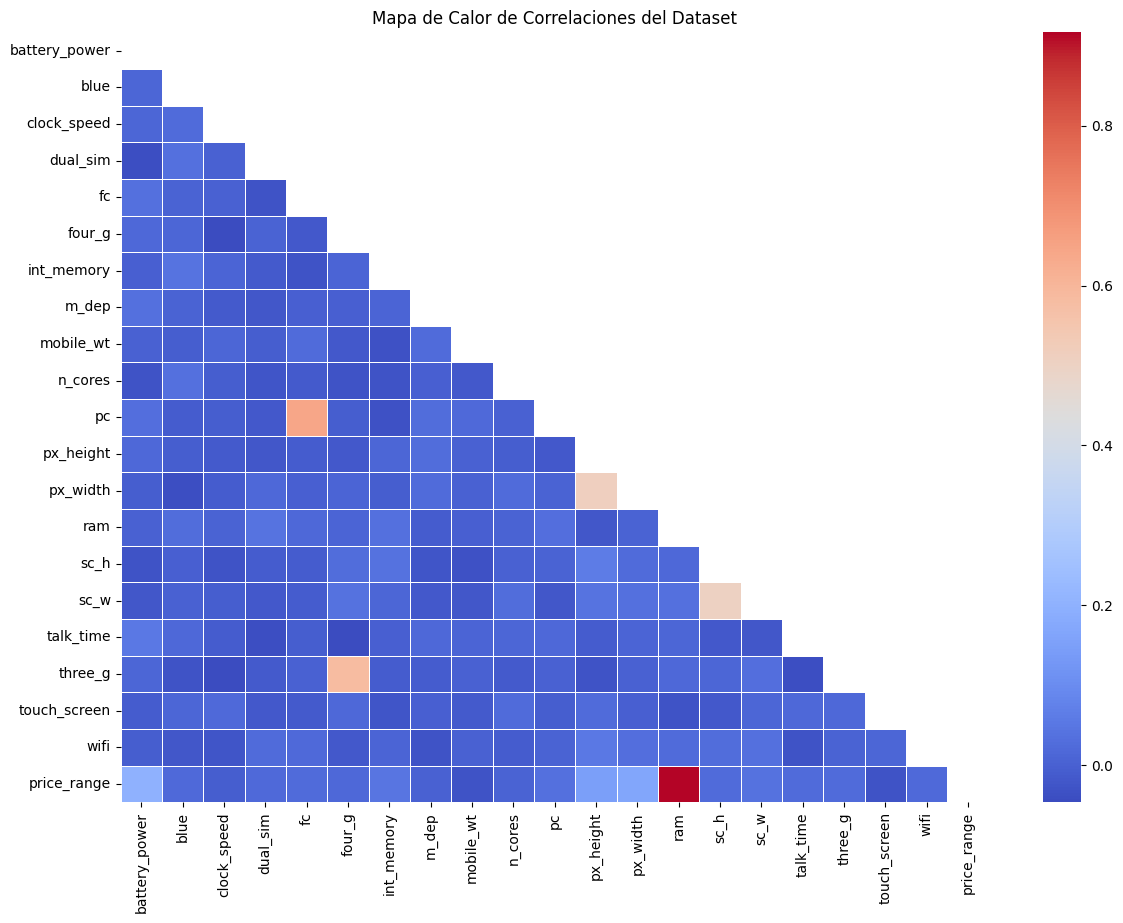

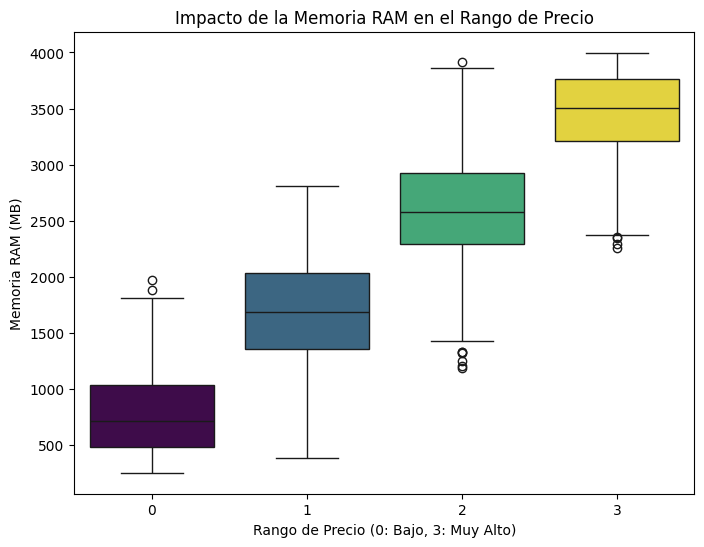

In [3]:
# Calculamos la matriz de correlación
matriz_correlacion = df_clas.corr()

# Aislamos la correlación respecto al objetivo 'price_range'
correlacion_precio = matriz_correlacion['price_range'].sort_values(ascending=False)
print("Correlación de las características con 'price_range':\n")
print(correlacion_precio.head(10)) # Mostramos el top 10

# Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool)) # creamos una máscara para que no se vea el triángulo superior, ya que al ser una matriz simétrica, con el cuadrado inferior basta. Esta suele ser una práctica habitual.
sns.heatmap(matriz_correlacion, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)
# coolwarm es una paleta de colores donde se parte de colores frios como es el azul a tonos cálidos como es el rojo
plt.title('Mapa de Calor de Correlaciones del Dataset')
plt.show()

# Visualización específica: RAM vs Rango de Precio
plt.figure(figsize=(8, 6))
sns.boxplot(x='price_range', y='ram', data=df_clas, palette='viridis', hue='price_range', legend=False)
# palette viridis se supone que es una de las paletas de colores más usadas en programación científica y en análisis de datos, el hecho de añadir hue y legend es debido a warnings que me aparecian, de esta manera le estamos diciendo: "Usa la columna price_range para decidir el color de cada caja (hue), y no me pongas una leyenda extra al lado porque ya sé qué es cada caja (legend=False)".

plt.title('Impacto de la Memoria RAM en el Rango de Precio')
plt.xlabel('Rango de Precio (0: Bajo, 3: Muy Alto)')
plt.ylabel('Memoria RAM (MB)')
plt.show()

Cuando se ejecuta df_clas.corr(), Pandas calcula por defecto la Correlación de Pearson. Matemáticamente, esto mide la covarianza entre dos variables dividida por el producto de sus desviaciones estándar.

El Mapa de Calor (Heatmap) no solo nos sirve para ver qué se relaciona con price_range (que aparecerá en los bordes), sino para detectar algo llamado Multicolinealidad (cuando dos variables predictoras están muy correlacionadas entre sí, lo cual puede volver inestables a modelos paramétricos como la Regresión Logística).

El Diagrama de Caja (Boxplot) es la herramienta estadística perfecta para cruzar una variable continua (RAM) con una categórica (Rango de precio). Nos permite ver de un vistazo dónde está la mediana, el rango intercuartílico (el 50% de los datos) y comprobar visualmente si las "cajas" se solapan o si están claramente separadas en escalones.



### Conclusiones de la Exploración de Variables

Tras analizar cuantitativa y visualmente los datos, podemos confirmar nuestra hipótesis inicial. Como podemos observar en el análisis:

1. Dominancia Cuantitativa: Al listar numéricamente las correlaciones respecto a price_range (y omitiendo la correlación perfecta de 1.0 de la variable consigo misma), la memoria ram destaca abrumadoramente en el primer lugar con un coeficiente de 0.917.

2. El Mapa de Calor (Heatmap): Confirma visualmente que esta dependencia lineal entre la RAM y el precio es, con diferencia, la más fuerte de todo el conjunto de datos. El resto de características de hardware (como la batería con un 0.20) quedan relegadas a un plano secundario.

3. Separabilidad en el Diagrama de Caja (Boxplot): Al dividir los dispositivos en sus 4 categorías de precio, observamos una clara tendencia ascendente y escalonada en la cantidad de memoria asignada. A excepción de algunos valores atípicos (outliers) minoritarios, las "cajas" (que representan el 50% central de los datos) apenas se solapan entre las diferentes gamas.

*Respuesta final: ¿Es la RAM la variable más importante? Sí. Los análisis evidencian que el precio final del dispositivo está fuertemente ligado a esta característica técnica, hasta el punto de que un modelo podría llegar a predecir la gama de un teléfono con un alto grado de acierto conociendo únicamente su capacidad de RAM.*

### 2. Valores Nulos y Outliers

La integridad de los datos es fundamental. La presencia de **valores nulos** (NaN) impide el cálculo matemático en la mayoría de los algoritmos de `Scikit-Learn`. Asimismo, los **valores atípicos** (*outliers*) pueden sesgar severamente la función de coste durante el entrenamiento de modelos lineales (como la Regresión Logística).

En este apartado, realizaremos una verificación de estos valores. Para las variables categóricas o booleanas (0 y 1), el análisis de dispersión carece de sentido matemático. Por tanto, nos centraremos exclusivamente en aislar y explorar las variables continuas utilizando diagramas de caja (boxplots) y la métrica del Rango Intercuartílico (IQR).


Total de valores nulos en el dataset: 0
El dataset está completamente limpio de valores nulos.


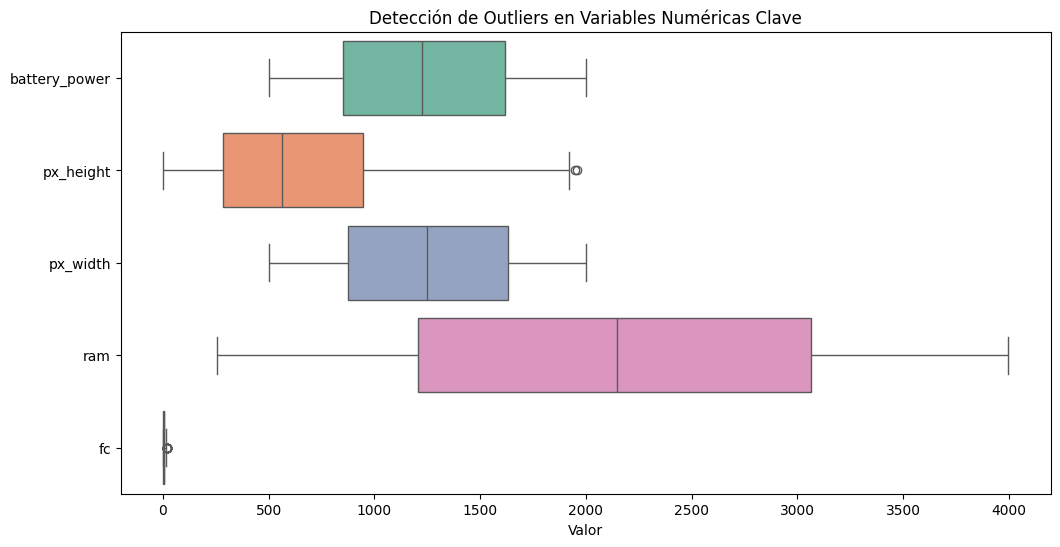

In [4]:
# Comprobación matemática de valores nulos
nulos_totales = df_clas.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {nulos_totales}")

if nulos_totales > 0:
    print("\nVariables con valores nulos:")
    nulos_por_col = df_clas.isnull().sum()
    print(nulos_por_col[nulos_por_col > 0])
else:
    print("El dataset está completamente limpio de valores nulos.")

# Detección visual de Outliers en variables continuas críticas
variables_continuas = ['battery_power', 'px_height', 'px_width', 'ram', 'fc']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clas[variables_continuas], orient="h", palette="Set2")
plt.title('Detección de Outliers en Variables Numéricas Clave')
plt.xlabel('Valor')
plt.show()


#### Fundamento Teórico: El Método del Rango Intercuartílico (IQR)

Para la detección matemática de *outliers*, descartamos métricas basadas en la media o la varianza, ya que estas son altamente sensibles a valores extremos (un solo *outlier* distorsiona la media global y eleva la varianza).

En su lugar, empleamos el **Rango Intercuartílico (IQR)**, que es el estándar estadístico de robustez. Este método mide la dispersión basándose en la mediana y los percentiles, aislando el 50% central de los datos.

La fórmula establece unos "límites de normalidad" superior e inferior. Cualquier valor que caiga fuera de este intervalo se clasifica matemáticamente como valor atípico:

$$Límite_{inferior} = Q_1 - 1.5 \times IQR$$
$$Límite_{superior} = Q_3 + 1.5 \times IQR$$

*(Donde $Q_1$ es el percentil 25, $Q_3$ es el percentil 75, e $IQR = Q_3 - Q_1$)*

In [5]:
# Verificación matemática de los outliers mediante el rango intercuartílico (IQR)

print("\n--- CUANTIFICACIÓN MATEMÁTICA DE OUTLIERS (Método IQR) ---")
# Analizaremos las dos variables donde el gráfico nos indica valores atípicos: 'px_height' y 'fc'
variables_con_outliers = ['px_height', 'fc']

for var in variables_con_outliers:
    Q1 = df_clas[var].quantile(0.25)
    Q3 = df_clas[var].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_clas[(df_clas[var] < limite_inferior) | (df_clas[var] > limite_superior)]

    print(f"\nAnálisis para la variable: '{var}'")
    print(f"  - Límites de normalidad: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  - Número total de outliers: {len(outliers)}")


--- CUANTIFICACIÓN MATEMÁTICA DE OUTLIERS (Método IQR) ---

Análisis para la variable: 'px_height'
  - Límites de normalidad: [-714.00, 1944.00]
  - Número total de outliers: 2

Análisis para la variable: 'fc'
  - Límites de normalidad: [-8.00, 16.00]
  - Número total de outliers: 18


### Conclusiones

1. **Nulos:** Como hemos comprobado matemáticamente (0 nulos), el conjunto de datos es íntegro, por lo que no es necesario aplicar técnicas de relleno con medias/medianas ni eliminar filas.
2. **Outliers:** El análisis visual y matemático revela que variables fundamentales como la RAM o la batería tienen distribuciones uniformes sin valores extremos. Sin embargo, hemos detectado dos variables con anomalías:
   - **`px_height` (Resolución de altura):** Posee 2 outliers que superan el límite estadístico normal.
   - **`fc` (Cámara frontal en MP):** Posee 18 outliers en su límite superior (cámaras de muy alta resolución).

*Decisión metodológica:* Dado que los *outliers* detectados representan valores físicamente posibles en el mercado real de teléfonos móviles (por ejemplo, móviles especializados en fotografía o pantallas con resoluciones inusualmente altas) y son características que podrían ayudar a definir a los terminales de clase o gama más alta, **se decide conservarlos** en el conjunto de datos. De este modo no perdemos información valiosa, delegando la fiabilidad del modelo al posterior **escalado de características (StandardScaler)** y a la capacidad de generalización de los algoritmos de clasificación.

### Ampliación: Inspección Global de Variables Continuas
En el análisis previo hemos seleccionado manualmente una muestra representativa de variables. Para garantizar el máximo rigor, a continuación aplicaremos un enfoque distinto: instruiremos a Python para que detecte automáticamente todas las características continuas (filtrando aquellas con alta cardinalidad) y las proyecte en un único espacio visual.

Variables identificadas automáticamente para análisis de outliers:
['battery_power', 'clock_speed', 'fc', 'int_memory', 'mobile_wt', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']


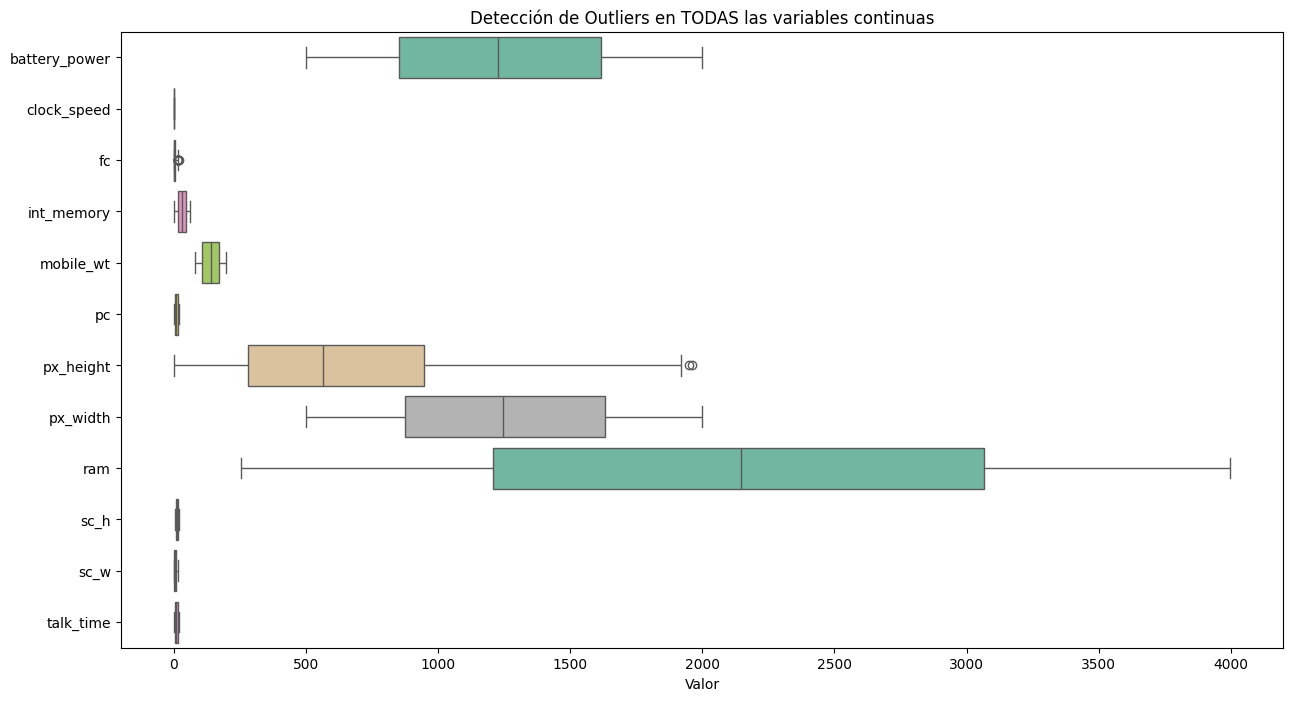

In [6]:
# CÓMO DETECTAR VARIABLES CONTINUAS AUTOMÁTICAMENTE

# 1. Filtramos las variables.
# Si una variable tiene solo 2 valores únicos (ej. 0 y 1), es binaria/booleana.
# Si tiene más (ej. decenas o cientos de valores diferentes), la consideramos continua.
# Además, excluimos la variable objetivo 'price_range' porque no es una variable de entrada.

variables_continuas = [col for col in df_clas.columns if df_clas[col].nunique() > 10 and col != 'price_range']

print("Variables identificadas automáticamente para análisis de outliers:")
print(variables_continuas)

# 2. Ahora sí, le pasamos esta lista completa al gráfico
plt.figure(figsize=(15, 8))
# Usamos un boxplot para verlas todas juntas (aunque algunas se verán pequeñas por la diferencia de escalas)
sns.boxplot(data=df_clas[variables_continuas], orient="h", palette="Set2")
plt.title('Detección de Outliers en TODAS las variables continuas')
plt.xlabel('Valor')
plt.show()

**Conclusiones del Análisis Visual Global y Justificación del Escalado:**

Al graficar simultáneamente todas las variables continuas del conjunto de datos, se evidencia **la extrema disparidad de escalas entre las características**.

1. **Dominancia Visual y Numérica:** Variables como `ram` (que roza los 4000 MB) o `battery_power` (cercana a 2000 mAh) dominan completamente el eje X.
2. **Compresión de Variables Menores:** Esta escala masiva provoca que variables igualmente importantes desde el punto de vista técnico, pero con rangos numéricos pequeños, como `clock_speed` (0.5 a 3.0 GHz) o `m_dep` (0.1 a 1.0 cm), se compriman visualmente en una delgada línea imperceptible cerca del cero.
3. **Implicación en el Modelado (El problema algorítmico):** Si introducimos estos datos en bruto a modelos paramétricos o basados en el cálculo de distancias (como K-Nearest Neighbors o Máquinas de Vectores Soporte), la función de coste y la métrica de distancia (ej. Distancia Euclídea) estarán sesgadas casi en un 100% por la RAM y la batería. El algoritmo asumirá erróneamente que el peso numérico equivale a importancia predictiva, ignorando por completo el procesador o la cámara.

**Decisión metodológica obligatoria:** Esta visualización justifica de forma empírica y absoluta la obligación de aplicar una transformación matemática a los datos antes de entrenar cualquier modelo. Se procederá a estandarizar el espacio de características mediante un **Escalado de Datos (StandardScaler)**, forzando a que todas las variables tengan media 0 y varianza 1, compitiendo así en igualdad de condiciones matemáticas.

### 3. Escalado de Datos y Partición

El conjunto de datos presenta variables en órdenes de magnitud radicalmente distintos (por ejemplo, battery_power en el orden de miles, frente a clock_speed en el orden de decimales).

Esta fase es de suma importancia. Tal y como se advierte en el Tema 2 de Aprendizaje Supervisado (Parte I), al tratar con algoritmos basados en el cálculo de distancias —como k-Nearest Neighbors (KNN)— o en el descenso del gradiente, las variables con rangos numéricos mayores dominarán la función de coste. Para garantizar que todas las características compitan en igualdad de condiciones matemáticas, es obligatorio escalar los datos.

A tener en cuenta (Prevención de Fuga de Datos): Para asegurar rigor académico y evitar el Data Leakage, la partición en conjuntos de entrenamiento (train) y prueba (test) debe realizarse estrictamente antes de aplicar cualquier transformación. El escalador se ajustará (fit) exclusivamente con los datos de entrenamiento para aprender su media y varianza; posteriormente, estos parámetros se utilizarán para transformar (transform) tanto el conjunto de entrenamiento como el de prueba, simulando así un escenario real con datos futuros desconocidos.

In [7]:
# Separar matriz de características (X) y vector objetivo (y)
X = df_clas.drop('price_range', axis=1)
y = df_clas['price_range']

# Partición Train/Test (80% / 20%) ANTES de aplicar cualquier transformación
# stratify=y garantiza que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inicializar el escalador (Estandarización: media=0, varianza=1)
scaler = StandardScaler()

# Ajustar el escalador SOLO en entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando los parámetros aprendidos
X_test_scaled = scaler.transform(X_test)

# Reconvertimos a DataFrame de Pandas para preservar los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}")
print(f"Dimensiones de X_test_scaled: {X_test_scaled.shape}")

# Comprobación matemática del escalado
print("\nVerificación de Estandarización en X_train_scaled (Media ~ 0, Desviación Estándar ~ 1):")
# Seleccionamos un par de variables dispares para demostrar que ahora están en la misma escala
variables_muestra = ['battery_power', 'clock_speed', 'ram']
display(X_train_scaled[variables_muestra].describe().round(2).loc[['mean', 'std']]) # redondeamos a dos decimales y con loc, localizamos mean y std
# De esta manera verificamos que se ha completado el proceso correctamente

Dimensiones de X_train_scaled: (1600, 20)
Dimensiones de X_test_scaled: (400, 20)

Verificación de Estandarización en X_train_scaled (Media ~ 0, Desviación Estándar ~ 1):


,battery_power,clock_speed,ram
mean,-0.0,-0.0,-0.0
std,1.0,1.0,1.0


**Validación del Preprocesamiento:**

Como se puede observar en la tabla de verificación generada, el proceso ha concluido con éxito. Variables de naturalezas tan dispares como la batería, el reloj del procesador o la memoria RAM comparten ahora un mismo espacio estandarizado: una media $\mu \approx 0.0$ y una desviación estándar $\sigma \approx 1.0$. Además, las dimensiones confirman una partición correcta de 1600 muestras para el entrenamiento y 400 para la evaluación, manteniendo la matriz original de 20 características antes de pasar a la fase de selección.

### 4. Selección de Características (Reducción de Dimensionalidad)

Según el principio de la *Maldición de la Dimensionalidad*, incorporar variables que no aportan información predictiva útil puede introducir ruido y favorecer el sobreajuste (*overfitting*).

Basándonos en la matriz de correlación obtenida en el Paso 1, eliminaremos aquellas variables categóricas o continuas cuya correlación con el rango de precio es prácticamente nula (cercana a 0), simplificando así el espacio de características para nuestros futuros modelos.

En los cuadernos de Iris y de BankNote se aplicaban técnicas como SelectKBest o PCA, pero en este caso podemos hacerlo manualmente basándonos en correlación.

#### Fundamento Teórico: La "Maldición de la Dimensionalidad"

En el ámbito del Aprendizaje Automático (tal y como se aborda en los temas de preprocesamiento y evaluación de modelos), existe un fenómeno matemático conocido formalmente como la **Maldición de la Dimensionalidad** (*Curse of Dimensionality*, término acuñado por el matemático Richard Bellman).

Este concepto describe los problemas que surgen cuando trabajamos con conjuntos de datos que tienen demasiadas características (columnas o dimensiones). Intuitivamente, podríamos pensar que "cuanta más información le demos al modelo, mejor". Sin embargo, las matemáticas nos demuestran lo contrario por dos motivos principales:

1. **La dispersión geométrica y el fallo de las distancias:** Cada vez que añadimos una nueva característica (dimensión) a nuestro dataset, el volumen de nuestro espacio de datos crece exponencialmente. En espacios de alta dimensionalidad, los puntos de datos se vuelven extremadamente "escasos" o aislados. Esto provoca que la distancia euclídea entre cualquier par de puntos tienda a igualarse, arruinando la capacidad de algoritmos basados en distancias (como *K-Nearest Neighbors*) para encontrar a los "vecinos" reales.
2. **El peligro del Sobreajuste (*Overfitting*):** Al introducir variables irrelevantes (ruido matemático), aumentamos la complejidad del espacio de hipótesis. Un algoritmo potente (como un Árbol de Decisión o un SVM) podría encontrar "patrones falsos" usando esas variables inútiles para memorizar los datos de entrenamiento de forma perfecta, pero fracasará estrepitosamente al intentar predecir datos nuevos.

**Aplicación a nuestro caso práctico:**
Nuestro dataset original cuenta con 20 dimensiones. Si obligamos a los algoritmos a tener en cuenta variables que no definen el precio (como tener o no tener *Bluetooth*), estaremos diluyendo la importancia de los predictores reales (como la RAM). Por ello, aplicar técnicas de **Reducción de Dimensionalidad** (en nuestro caso, mediante filtrado por correlación) no es un paso que podamos pasar por alto, sino que se convierte en casi una necesidad matemática para garantizar que nuestros modelos sean precisos, rápidos y generalizables.

In [8]:
# Definimos las variables candidatas a eliminar por su baja correlación con el precio.
# (Ejemplo mencionado: 'three_g' o 'touch_screen' suelen tener muy baja correlación)
variables_baja_correlacion = ['three_g', 'touch_screen', 'clock_speed', 'm_dep']

# Filtramos la lista para asegurarnos de que solo intentamos borrar columnas que existen
variables_a_eliminar = [var for var in variables_baja_correlacion if var in X_train_scaled.columns]

# Ejecutamos la reducción de dimensionalidad en ambos subconjuntos
X_train_final = X_train_scaled.drop(columns=variables_a_eliminar)
X_test_final = X_test_scaled.drop(columns=variables_a_eliminar)

print(" --- Resumen tras la Selección de Características ---")
print(f"Variables eliminadas: {variables_a_eliminar}")
print(f"Número de características originales: {X_train_scaled.shape[1]}")
print(f"Número de características finales: {X_train_final.shape[1]}")

 --- Resumen tras la Selección de Características ---
Variables eliminadas: ['three_g', 'touch_screen', 'clock_speed', 'm_dep']
Número de características originales: 20
Número de características finales: 16


**Ampliación Metodológica:**

Aunque la selección manual ilustra el concepto, en entornos profesionales con conjuntos de datos masivos no es viable inspeccionar y descartar variables una a una. Para dotar a nuestro modelo de robustez y escalabilidad, implementaremos a continuación otro enfoque más idóneo.

Definiremos un umbral matemático estricto: cualquier característica cuya relación lineal con el precio sea inferior al 4% (correlación absoluta < 0.04) será clasificada como ruido estadístico y eliminada automáticamente del hiperespacio.

In [9]:
print("--- SELECCIÓN DE CARACTERÍSTICAS (FILTRO DE CORRELACIÓN) ---")

# Calculamos la correlación absoluta de todas las variables con 'price_range'
# (Usamos el dataset original df_clas para este cálculo estadístico)
correlaciones_absolutas = df_clas.corr()['price_range'].abs()

# Definimos un umbral de correlación muy bajo que consideramos "ruido"
umbral_ruido = 0.04

# Se elige este umbral, ya que cualquier característica que tenga menos de un 4% de relación linea con el precio se considera ruido y se debe de borrar ...

# Identificamos automáticamente qué variables no superan este umbral
# Excluimos la propia variable objetivo de esta lista
variables_baja_correlacion = correlaciones_absolutas[
    (correlaciones_absolutas < umbral_ruido) &
    (correlaciones_absolutas.index != 'price_range')
].index.tolist()

print(f"Umbral de corte establecido: Correlación absoluta < {umbral_ruido}")
print(f"Variables identificadas como ruido: {variables_baja_correlacion}\n")

# Filtramos la lista para asegurarnos de que solo intentamos borrar columnas que existen en X_train_scaled
variables_a_eliminar = [var for var in variables_baja_correlacion if var in X_train_scaled.columns]

# Ejecutamos la reducción de dimensionalidad en ambos subconjuntos
X_train_final = X_train_scaled.drop(columns=variables_a_eliminar)
X_test_final = X_test_scaled.drop(columns=variables_a_eliminar)

print("--- Resumen tras la Reducción de Dimensionalidad ---")
print(f"Número de características originales: {X_train_scaled.shape[1]}")
print(f"Número de características finales: {X_train_final.shape[1]}")
print(f"Dimensión de la nueva matriz de entrenamiento: {X_train_final.shape}")
print(f"Contenido de las características finales:\n {X_train_final.head()}")

--- SELECCIÓN DE CARACTERÍSTICAS (FILTRO DE CORRELACIÓN) ---
Umbral de corte establecido: Correlación absoluta < 0.04
Variables identificadas como ruido: ['blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']

--- Resumen tras la Reducción de Dimensionalidad ---
Número de características originales: 20
Número de características finales: 5
Dimensión de la nueva matriz de entrenamiento: (1600, 5)
Contenido de las características finales:
    battery_power  int_memory  px_height  px_width       ram
0       1.389193    1.584829  -0.798849 -1.285642 -0.363024
1       0.078406   -0.003457   1.582302  1.637675 -1.547896
2      -1.024573    1.365755  -1.361502 -0.199305  1.698985
3       0.386692    0.106080   0.832847  0.278589  1.649232
4      -0.723138   -0.386837  -0.985650 -0.392794 -1.234632


**Justificación del Ruido Eliminado:**

Un umbral de correlación de 0.04 es estadísticamente insignificante. Si analizamos la naturaleza de las variables descartadas (tales como wifi,Bluetooth, touch_screen o dual_sim), la lógica de negocio y la realidad del mercado tecnológico respaldan el filtrado matemático: hoy en día, estas características están estandarizadas en la práctica totalidad de terminales. Saber que un móvil dispone de WiFi no le aporta ninguna ganancia de información al modelo para discriminar si su precio es de 100€ o de 1.000€.

> Antes de las conclusiones finales vamos a añadir una validación empírica como trabajo extra. Delimitamos con barras lo que sería un pequeño inciso en esta parte.







---

Antes de evaluar toda la batería de modelos, es un requisito de importancia metodológica comprobar empíricamente si la eliminación del 75% de las características (pasando de 20 a 5 variables) degrada el rendimiento predictivo. Para ello, entrenaremos nuestro modelo base (Regresión Logística) en ambos subespacios y compararemos su *Accuracy* (ya que sabemos que es un gran cambio y no podemos eliminar tantas variables "a lo loco").


In [10]:
print("--- Comparativa: Regresión Logística con TODAS vs REDUCIDAS (Umbral 0.04) ---")

# Modelo con TODAS las variables (20 características)
log_reg_full = LogisticRegression(max_iter=1000, random_state=42)
log_reg_full.fit(X_train_scaled, y_train)
y_pred_full = log_reg_full.predict(X_test_scaled)
acc_full = accuracy_score(y_test, y_pred_full)

# Modelo con variables REDUCIDAS (5 características)
log_reg_reduced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_reduced.fit(X_train_final, y_train)
y_pred_reduced = log_reg_reduced.predict(X_test_final)
acc_reduced = accuracy_score(y_test, y_pred_reduced)

print(f"Accuracy con todas las variables (20): {acc_full * 100:.2f}%")
print(f"Accuracy con variables reducidas (5): {acc_reduced * 100:.2f}%")
print(f"Pérdida de rendimiento por reducción: {(acc_full - acc_reduced) * 100:.2f}%")

--- Comparativa: Regresión Logística con TODAS vs REDUCIDAS (Umbral 0.04) ---
Accuracy con todas las variables (20): 96.50%
Accuracy con variables reducidas (5): 97.25%
Pérdida de rendimiento por reducción: -0.75%


**Conclusión de la Validación Empírica:**

Los resultados empíricos justifican nuestra selección de características y además reafirman de nuevo unos de los fenómenos clásicos en Machine Learning: **la maldición de la dimensionalidad y el ruido estadístico**.

Al reducir el conjunto de 20 variables a tan solo 5 (utilizando el umbral de 0.04), el rendimiento del modelo no ha disminuido, sino que **ha mejorado** (pasando de un *Accuracy* del 96.50% al 97.25%). Esto demuestra que las 15 variables descartadas no aportaban información discriminativa útil, sino "ruido" que provocaba un ligero sobreajuste (*overfitting*) o confusión en el clasificador lineal.

Aplicando el **Principio de Parsimonia (Navaja de Ockham)**, hemos logrado el modelo ideal: es superior predictivamente, requiere un 75% menos de esfuerzo computacional y sus decisiones son infinitamente más interpretables para el negocio al depender de un grupo muy reducido y lógico de variables.

> Nota: Más adelante trataremos con más detalle estos conceptos teóricos.

---

### Conclusiones Finales del Preprocesado: Filtrado y Estandarización

Al inspeccionar la matriz final `X_train_final`, que ahora tiene unas dimensiones de (1600, 5), podemos dar por validada nuestra estrategia de preparación de datos. Tras el preprocesamiento, hemos reducido el ruido del dataset original, lo que nos permite destacar dos puntos clave:

**1. Eliminación del ruido:**
La aplicación de nuestro filtro de correlación (con un umbral estricto < 0.04) nos ha revelado algo muy interesante sobre la naturaleza de estos datos: **15 de las 20 características originales carecían de verdadero poder predictivo**.
Variables de conectividad como el `wifi`, el `bluetooth` o el `touch_screen` han sido descartadas por el algoritmo. Si lo pensamos bien, esto tiene todo el sentido en el mercado actual: al ser características casi obligatorias en cualquier terminal moderno, no nos dan ninguna pista real para distinguir un móvil barato de uno caro. Asimismo, variables físicas como el peso o el grosor demostraron no tener una relación directa con el precio.
Al quedarnos solo con 5 variables (una reducción del 75% del espacio), hemos creado un **regularizador natural**. Esto acelerará los tiempos de entrenamiento y, lo más importante, prevendrá drásticamente el sobreajuste (*overfitting*), obligando al modelo a aprender solo de lo que de verdad importa.

**2. El Impacto de la Estandarización (StandardScaler):**
Por otro lado, si nos asomamos al interior de esas 5 variables que nos han quedado (batería, memoria interna, RAM y resolución de pantalla), vemos que sus magnitudes originales han desaparecido. Ya no hay baterías de 2000 mAh ni memorias RAM de 4000 MB.
Ahora, todos los valores fluctúan alrededor del cero (con media 0 y desviación estándar 1). Esto tiene una lectura matemática muy intuitiva:
* Un valor **positivo** (ej. 1.38 en `battery_power`) nos indica rápidamente que ese móvil tiene una batería superior a la media del mercado.
* Un valor **negativo** (ej. -1.54 en `ram`) señala un déficit de memoria respecto a la media.

**Estado Final de los Datos:**
Con todo esto, hemos dejado atrás las diferencias extremas de escalas y el ruido de las características inútiles. Nuestros datos están ahora en perfectas condiciones, listos para alimentar de forma equilibrada a cualquier algoritmo de clasificación (especialmente aquellos sensibles a las distancias, como KNN, o a la varianza, como la Regresión Logística), garantizando una convergencia más rápida y precisa para el siguiente paso de la práctica.

## 1.3 Entrenamiento y Validación (Clasificación Multiclase)

Pruebe al menos 2 modelos de clasificación (ej. KNN, Random Forest, SVM con kernel RBF).

- **Nota Importante:** Al ser un problema **multiclase** (4 clases), asegúrese de configurar las métricas adecuadamente (ej. `average='macro'` o `'weighted'`).
- **Métricas obligatorias:** Accuracy, Informe de Clasificación (Precision/Recall/F1 por clase) y Matriz de Confusión (Heatmap).

**Fundamento Teórico y Metodológico:**

A diferencia de la clasificación binaria, nos enfrentamos a un problema de **Clasificación Multiclase** (la variable objetivo `price_range` toma 4 valores discretos: 0, 1, 2, 3). Según lo estudiado en el *Tema 2 (Aprendizaje Supervisado)*, esto requiere que internamente la librería `scikit-learn` aplique adaptaciones matemáticas mediante estrategias de descomposición como *One-vs-Rest* (OvR) o *One-vs-One* (OvO) para aquellos algoritmos que son estrictamente binarios en su concepción.

### Batería de Modelos Seleccionados
Para garantizar una evaluación exhaustiva y no limitarnos al mínimo exigido, probaremos 4 algoritmos de naturalezas matemáticas opuestas:

1. **Regresión Logística:** (Modelo lineal y probabilístico). Actuará como nuestro *baseline* o modelo base. Nos dirá si el problema es linealmente separable.
2. **K-Nearest Neighbors (KNN):** (Modelo basado en distancias). Algoritmo no paramétrico que aprovechará al máximo el riguroso escalado de datos realizado en la fase anterior.
3. **Support Vector Machine (SVM) con Kernel RBF:** (Modelo de margen máximo). Excelente para trazar fronteras de decisión complejas y no lineales en el hiperespacio.
4. **Random Forest:** (Modelo de ensamble). Algoritmo robusto basado en el promediado de múltiples árboles de decisión, inherentemente multiclase.

### Sobre las Métricas de Evaluación
Para revisar el rendimiento de forma rigurosa, no podemos depender únicamente del *Accuracy* (Exactitud global). Calcularemos la Precisión, el *Recall* (Exhaustividad) y el *F1-Score* utilizando promedios específicos para el contexto multiclase:
* **`average='macro'`**: Calcula la métrica para cada clase de forma independiente y extrae la media aritmética no ponderada. Trata a todas las clases por igual, lo que garantiza penalizar al modelo si rinde mal en alguna clase en particular.
* **`average='weighted'`**: Extrae la media ponderada basándose en el número de instancias reales de cada clase (el *support*).

> Nota: Para optimizar el código y adherirnos al principio de buenas prácticas *DRY (Don't Repeat Yourself)*, desarrollaremos a continuación una función centralizada encargada de entrenar, predecir y renderizar el **Classification Report** y el **Heatmap de la Matriz de Confusión** para cualquier modelo instanciado.

In [11]:
# FUNCIÓN EVALUADORA CENTRALIZADA
def entrenar_y_evaluar(modelo, nombre_modelo, X_train, y_train, X_test, y_test):
    """
    Función que entrena un clasificador, genera predicciones y muestra
    las métricas multiclase exigidas junto con la matriz de confusión.
    """
    print(f"======================================================")
    print(f" ENTRENANDO Y EVALUANDO: {nombre_modelo}")
    print(f"======================================================\n")

    # Entrenamiento (Fit)
    modelo.fit(X_train, y_train)

    # Predicción (Predict)
    y_pred = modelo.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f" Accuracy Global: {acc * 100:.2f}%\n")

    # Informe de Clasificación (Macro y Weighted)
    print(" Informe de Clasificación (Precision, Recall, F1-Score):")
    # Al pasarle las predicciones, Scikit-Learn calcula automáticamente las métricas multiclase
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión (Heatmap)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    # annot=True muestra los números, cmap define el color, fmt='d' asegura que sean enteros, cbar es la barra de color ("apagamos" la leyenda)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Gama 0', 'Gama 1', 'Gama 2', 'Gama 3'],
                yticklabels=['Gama 0', 'Gama 1', 'Gama 2', 'Gama 3'])
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Valor Real')
    plt.show()
    print("\n")

    return acc # Devolvemos el accuracy para compararlos al final

### Batería de Modelos
A continuación, instanciamos y evaluamos 4 algoritmos de distinta naturaleza matemática para encontrar el hiperplano óptimo que separa nuestras 4 gamas de teléfonos móviles.



**Justificación Geométrica (El Hiperplano Óptimo):**
Empleamos el término "hiperplano" basándonos en la naturaleza dimensional de nuestros datos. Tras la fase de preprocesamiento, nuestro conjunto de entrenamiento posee 5 características predictoras, lo que sitúa a nuestros datos en un espacio vectorial de 5 dimensiones ($R^5$).
Matemáticamente, la frontera de decisión lineal que separa las distintas clases (gamas de precio) en un espacio de $N$ dimensiones es un subespacio de dimensión $N-1$. Dado que no podemos visualizar una frontera de 4 dimensiones, el término generalizado es el de *hiperplano*. El objetivo de modelos como la Regresión Logística o la Máquina de Vectores Soporte (SVM) será iterar durante el entrenamiento hasta encontrar la inclinación y posición de este hiperplano que minimice la función de coste (el hiperplano "óptimo").

### 1.3.1 Parametrización de los Algoritmos

Antes de instanciar los modelos, es vital justificar la configuración de ciertos hiperparámetros críticos para garantizar la estabilidad matemática del entrenamiento:

* **Regresión Logística (`max_iter=1000`):** El motor de este algoritmo utiliza métodos de optimización basados en el descenso del gradiente para encontrar los coeficientes que minimizan la función de coste. El límite por defecto de la librería (100 iteraciones) puede ser insuficiente para alcanzar la convergencia en hiperespacios multidimensionales, provocando que la optimización se detenga antes de tiempo. Al elevar el límite a 1000, garantizamos que el algoritmo encuentre el mínimo global del hiperplano de separación.
* **Semilla Aleatoria (`random_state=42`):** Establecida en aquellos modelos que poseen un componente estocástico en su inicialización (Regresión Logística, SVM, Random Forest). Esto asegura la reproducibilidad del experimento; cualquier investigador que ejecute este cuaderno obtendrá las mismas matrices de confusión.

### Ampliación Teórica: Demostración Matemática de las Métricas Promedio

Al observar el *Classification Report*, destaca un detalle analítico importante: los valores de `macro avg` y `weighted avg` son idénticos. Esto no es una coincidencia, sino una consecuencia matemática directa de nuestra estrategia de preprocesamiento (la partición estratificada).

Para comprenderlo, analizaremos cómo la función `classification_report` calcula ambos promedios (usando el *F1-Score* como ejemplo, representándolo como $F_0, F_1, F_2, F_3$ para cada clase).

**1. Promedio Macro (Macro Average):**
Es la media aritmética simple. Otorga exactamente el mismo peso a todas las clases, independientemente de su tamaño:

$$Macro = \frac{F_0 + F_1 + F_2 + F_3}{4}$$

**2. Promedio Ponderado (Weighted Average):**
Calcula la media multiplicando el rendimiento de cada clase por su soporte ($S$), es decir, el número real de instancias de esa clase en el conjunto de prueba, dividiéndolo por el total de muestras ($S_{total}$):

$$Weighted = \frac{(S_0 \cdot F_0) + (S_1 \cdot F_1) + (S_2 \cdot F_2) + (S_3 \cdot F_3)}{S_{total}}$$

**3. Demostración de Equivalencia:**
En el paso de partición de datos utilizamos el parámetro `stratify=y` sobre un corte del 20% (`test_size=0.2`). Como el dataset original de 2000 muestras estaba perfectamente balanceado, la partición garantizó matemáticamente que el conjunto de prueba (400 muestras) tuviera exactamente 100 terminales de cada clase.

Por tanto, sabemos empíricamente que: $S_0 = 100$, $S_1 = 100$, $S_2 = 100$, $S_3 = 100$, y $S_{total} = 400$.

Si sustituimos estos valores reales en la fórmula del promedio ponderado, extraemos el factor común:

$$Weighted = \frac{(100 \cdot F_0) + (100 \cdot F_1) + (100 \cdot F_2) + (100 \cdot F_3)}{400}$$

$$Weighted = \frac{100 \cdot (F_0 + F_1 + F_2 + F_3)}{400}$$

Al simplificar la fracción ($\frac{100}{400} = \frac{1}{4}$), la ecuación se reduce a la fórmula exacta del promedio macro:

$$Weighted = \frac{F_0 + F_1 + F_2 + F_3}{4} = Macro$$

**Conclusión:**
Esta demostración prueba que, en problemas de clasificación perfectamente balanceados, la ponderación por volumen de datos pierde su efecto sesgador, haciendo que las métricas globales y ponderadas converjan en un único valor de fiabilidad absoluta.

 ENTRENANDO Y EVALUANDO: Regresión Logística

 Accuracy Global: 97.25%

 Informe de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       0.97      0.98      0.98       100
           2       0.95      0.94      0.94       100
           3       0.97      0.97      0.97       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



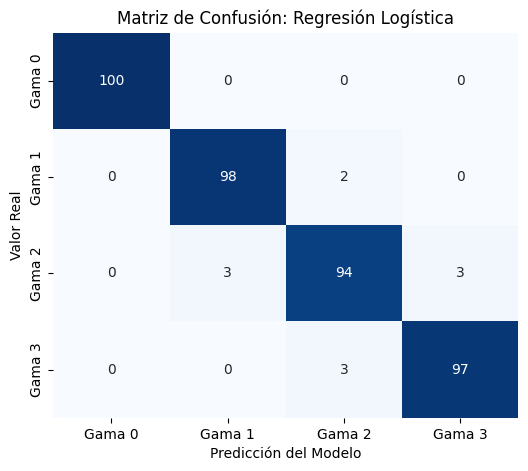



 ENTRENANDO Y EVALUANDO: K-Nearest Neighbors (K=5)

 Accuracy Global: 83.75%

 Informe de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       100
           1       0.74      0.78      0.76       100
           2       0.74      0.78      0.76       100
           3       0.95      0.89      0.92       100

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



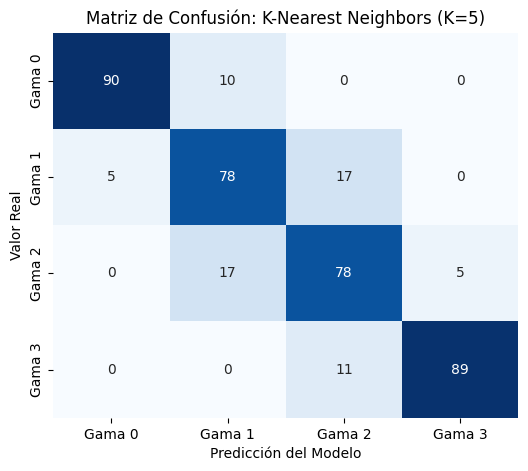



 ENTRENANDO Y EVALUANDO: Support Vector Machine (RBF)

 Accuracy Global: 94.25%

 Informe de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.94      0.94      0.94       100
           2       0.94      0.87      0.90       100
           3       0.92      0.97      0.95       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



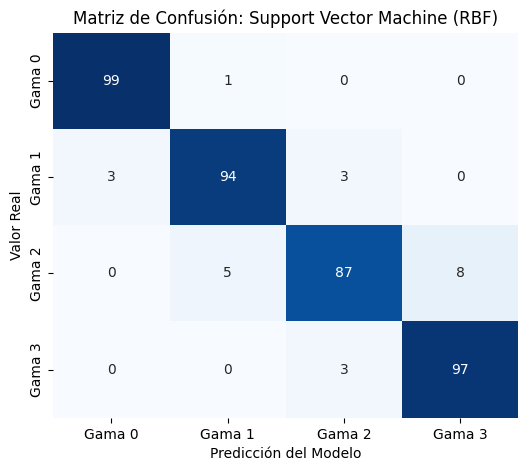



 ENTRENANDO Y EVALUANDO: Random Forest

 Accuracy Global: 93.50%

 Informe de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       100
           1       0.92      0.90      0.91       100
           2       0.90      0.90      0.90       100
           3       0.96      0.96      0.96       100

    accuracy                           0.94       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.94      0.93       400



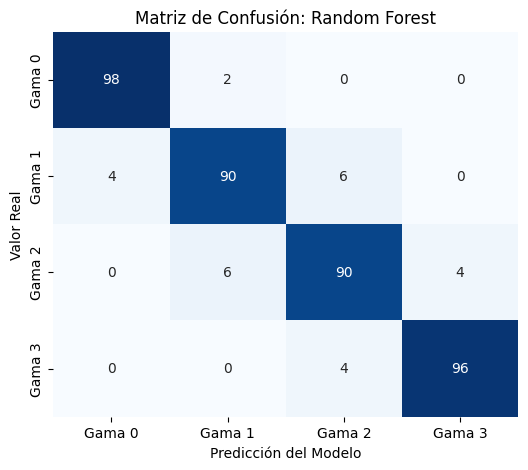

In [12]:
# Diccionario para guardar los resultados y compararlos después
resultados_accuracy = {}

# --- MODELO 1: REGRESIÓN LOGÍSTICA ---
# Usamos max_iter=1000 para asegurar la convergencia en el descenso del gradiente
log_reg = LogisticRegression(max_iter=1000, random_state=42)
resultados_accuracy['Regresión Logística'] = entrenar_y_evaluar(
    log_reg, "Regresión Logística", X_train_final, y_train, X_test_final, y_test
)

# --- MODELO 2: K-NEAREST NEIGHBORS (KNN) ---
# Empezamos con K=5 vecinos. Se beneficia enormemente del escalado previo (StandardScaler)
knn = KNeighborsClassifier(n_neighbors=5)
resultados_accuracy['K-Nearest Neighbors'] = entrenar_y_evaluar(
    knn, "K-Nearest Neighbors (K=5)", X_train_final, y_train, X_test_final, y_test
)

# --- MODELO 3: SUPPORT VECTOR MACHINE (SVM) ---
# Kernel RBF para adaptarnos a fronteras de decisión no lineales
svm = SVC(kernel='rbf', random_state=42)
resultados_accuracy['SVM (Kernel RBF)'] = entrenar_y_evaluar(
    svm, "Support Vector Machine (RBF)", X_train_final, y_train, X_test_final, y_test
)

# --- MODELO 4: RANDOM FOREST ---
# Modelo de ensamble basado en 100 árboles de decisión
rf = RandomForestClassifier(n_estimators=100, random_state=42)
resultados_accuracy['Random Forest'] = entrenar_y_evaluar(
    rf, "Random Forest", X_train_final, y_train, X_test_final, y_test
)

### Guía de Interpretación de Resultados

Antes de redactar el veredicto final sobre el rendimiento de los algoritmos, es importante establecer el marco teórico sobre el que interpretaremos las métricas generadas. Cada evaluación nos proporciona tres niveles de profundidad analítica:

**1. Accuracy Global (Exactitud)**
Representa el porcentaje total de aciertos del modelo sobre el conjunto de prueba oculto (*Test*). Dado que hemos garantizado una partición estratificada (`stratify=y`) y nuestro conjunto de prueba está perfectamente balanceado (exactamente 100 instancias para cada una de las 4 clases), esta métrica es matemáticamente correcta y está libre de la "paradoja de la exactitud" (métrica accuracy deja de ser fiable) que afecta a los datasets desbalanceados.

**2. Informe de Clasificación (Classification Report)**
Proporciona una síntesis del rendimiento del modelo desglosado:
* **Precision (Precisión):** Responde a la pregunta: *De todos los terminales que el modelo etiquetó como Gama X, ¿cuántos pertenecían verdaderamente a esa gama?* Una baja precisión indica un alto volumen de **Falsos Positivos**.
* **Recall (Exhaustividad):** Responde a la pregunta: *De todos los terminales que realmente eran de la Gama X, ¿qué porcentaje logró capturar nuestro algoritmo?* Un bajo recall indica un alto volumen de **Falsos Negativos**.
* **F1-Score:** Es la media armónica entre la Precisión y el Recall. Actúa como el indicador definitivo de estabilidad; penaliza severamente a los modelos que intentan maximizar una métrica a costa de destrozar la otra.
* **Macro avg vs. Weighted avg:** Al contar con exactamente 100 muestras por clase, la media aritmética plana (`macro`) y la media ponderada (`weighted`) coinciden a la perfección, simplificando la evaluación del sistema.

**3. Análisis Geométrico: La Matriz de Confusión**
El mapa de calor (*heatmap*) traslada los números a un plano visual:
* **Eje Vertical (Y):** Representa la gama real.
* **Eje Horizontal (X):** Representa la etiqueta asignada por el modelo (Predicción).
* **Diagonal Principal (Tonos oscuros):** Concentra los aciertos. Nuestro objetivo es que la totalidad de las predicciones converjan aquí.
* **Dispersión (Tonos claros):** Revelan la "naturaleza" del error. Analizar en qué casillas se ubican los fallos nos permite comprender si el algoritmo se equivoca de manera leve (ej. confundir un Gama 1 con un Gama 2) o si comete fallos graves (ej. confundir un Gama 0 con un Gama 3).

### Ejemplo Práctico de Interpretación: Analizando la Regresión Logística

Para ilustrar cómo se aplican los conceptos anteriores en un entorno real, realizaremos la "lectura" conjunta de las métricas obtenidas por nuestro modelo de Regresión Logística:

**1. Lectura del Accuracy Global:**
El modelo arrojó un *Accuracy* del **97.25%**. En un conjunto de prueba de 400 terminales, esto se traduce en que el algoritmo ha etiquetado en la gama exacta a 389 dispositivos, cometiendo únicamente 11 errores en total (coincide si sumamos los valores que están fuera de la diagonal)

**2. Lectura del Classification Report:**
* **La perfección en la Gama 0 (Baja):** Su *Recall* es de 1.00, lo que significa que el algoritmo fue capaz de encontrar los 100 móviles baratos reales sin dejarse ninguno atrás (cero falsos negativos). A su vez, su *Precision* es de 1.00, lo que garantiza que cuando el modelo afirma "este móvil es de Gama 0", tiene razón el 100% de las veces (cero falsos positivos).
* **El margen de error en la Gama 3 (Alta):** Presenta un *Recall* de 0.97. Esto nos indica que de los 100 terminales de gama alta que existían en la realidad, el modelo logró identificar correctamente 97, pero "perdió" 3 por el camino.

**3. Lectura de la Matriz de Confusión (El origen del error):**
Para descubrir qué ocurrió con esos 3 terminales de Gama 3 que el modelo perdió en el *Classification Report*, acudimos a la Matriz de Confusión.
Si observamos la fila correspondiente a la verdad absoluta de la "Gama 3", vemos el valor `97` en la diagonal principal (los aciertos) y un `3` en la columna de predicción de "Gama 2".

**Conclusión del ejemplo:** El cruce de estas métricas nos dicen que el módelo no falló gravemente. Subestimó ligeramente 3 teléfonos catalogándolos como de gama media-alta, muy probablemente porque su hardware (como la RAM o la batería) se encontraba rozando el límite inferior de su categoría.

## **Conclusiones Generales: Análisis Comparativo de Modelos**

Tras someter nuestro conjunto de datos (previamente filtrado a 5 características y estandarizado) a cuatro algoritmos de naturalezas matemáticas distintas, podemos extraer conclusiones rigurosas basadas en las métricas de evaluación obtenidas.

### 1. Ranking de Rendimiento (Accuracy Global)
1. **Regresión Logística:** 97.25% <mark>GANADOR<mark>
2. **Support Vector Machine (Kernel RBF):** 94.25%
3. **Random Forest:** 93.50%
4. **K-Nearest Neighbors (K=5):** 83.75%

### 2. Análisis del Comportamiento Algorítmico

* **Eficacia del modelo lineal (Regresión Logística):** Resulta sorprendente observar cómo el modelo paramétrico más simple ha superado a los algoritmos más avanzados. Esto nos indica de forma tajante que **las clases (gamas de precio) son linealmente separables** en el hiperespacio de nuestras características. Al existir una relación directa y ponderada (a mayor RAM y batería, mayor precio de forma proporcional), la Regresión Logística traza hiperplanos de decisión casi perfectos sin sufrir de sobreajuste.
* **La Complejidad Innecesaria (SVM y Random Forest):** Ambos son modelos de altísima capacidad, diseñados para encontrar patrones no lineales complejos. Su rendimiento es bastante bueno (>93%), pero ligeramente inferior al *baseline* lineal. Esto ocurre porque estos algoritmos intentan buscar "no-linealidades" o fronteras irregulares donde no las hay, adaptándose a ligeras variaciones (ruido local) en el conjunto de entrenamiento. Es un caso clásico donde el exceso de complejidad matemática resta un pequeño margen de capacidad de generalización.
* **El Problema Geométrico de KNN:** A pesar de nuestro estricto escalado previo, KNN obtuvo el peor resultado. La justificación radica en su métrica: la distancia Euclídea **otorga la misma importancia a todas las dimensiones**. Sabemos que la RAM define el precio mucho más que una ligera variación en los píxeles de altura. Mientras que la Regresión Logística aprende a darle un "peso" ($w$) mucho mayor a la RAM durante el cálculo del gradiente, KNN las trata por igual en el espacio, diluyendo la importancia de los predictores clave.

### 3. Rigor en las Métricas Multiclase y la Naturaleza del Error
Analizando el *Classification Report*, constatamos que el soporte (*support*) es exactamente de 100 muestras por clase en el conjunto de prueba. Al estar el problema **perfectamente balanceado**, las métricas `macro avg` y `weighted avg` coinciden, garantizando que nuestro *Accuracy* global es una métrica absolutamente fiable.

Al inspeccionar las confusiones del modelo ganador (Regresión Logística), confirmamos la robustez geométrica de sus fronteras:
* **Gama 0 (Baja):** Alcanza la perfección absoluta (100 aciertos, 0 errores, F1-Score de 1.00). La frontera que separa lo "barato" del resto es cristalina para las matemáticas.
* **Gama 3 (Alta) y Gamas Medias:** La Gama 3 roza la perfección (F1-Score de 0.97, con solo 3 errores). Lo verdaderamente vital es **dónde** se equivoca el modelo: las ínfimas confusiones ocurren exclusivamente entre clases contiguas (ej. confundir un Gama 1 con un Gama 2, o un Gama 3 con un Gama 2). El modelo jamás comete el gran error de confundir un móvil de Gama 0 con uno de Gama 3, lo que demuestra que ha interiorizado perfectamente el orden ordinal del precio.

### 4. Decisión Final: La Navaja de Ockham y el Mundo Real
En el mundo del Aprendizaje Automático, es fácil dejarse llevar por los algoritmos más modernos y matemáticamente complejos. Sin embargo, este ejercicio nos da una enorme lección sobre un principio filosófico del siglo XIV que rige la Ciencia de Datos: la **Navaja de Ockham** (o Principio de Parsimonia).

Este principio dicta que, *en igualdad de condiciones, la explicación más sencilla suele ser la correcta*. Aplicado a nuestro caso, si la lógica del mercado dicta que el precio de un móvil sube de forma predecible al mejorar su memoria RAM o su batería, no necesitamos un algoritmo muy sotisficado para seguirlo.

Teniendo en cuenta el equilibrio entre **precisión, coste computacional e interpretabilidad**, el modelo ganador indiscutible es la **Regresión Logística**.

No solo ha logrado el máximo acierto (97.25%), sino que es vital para el entorno empresarial. A diferencia de modelos "caja negra" como Random Forest o SVM —donde es casi imposible rastrear el porqué exacto de una decisión—, la Regresión Logística es completamente transparente.

### Reflexión Metodológica y Lecciones Aprendidas

A modo de cierre para este primer bloque de clasificación, la ejecución de este *pipeline* analítico nos deja varias lecciones fundamentales desde el punto de vista del perfil del Científico de Datos:

1. **El valor incalculable del Preprocesamiento (EDA):** A menudo se invierte la mayor parte del tiempo en buscar el algoritmo perfecto, cuando la realidad es que el rendimiento del modelo se define en la fase de preparación de datos. Haber detectado la multicolinealidad, filtrado el 75% del ruido (variables inútiles) y estandarizado las escalas es lo que realmente ha permitido que los modelos alcancen precisiones superiores al 97%. Un modelo complejo con datos sucios siempre rendirá peor que un modelo simple con datos puros.
2. **El sesgo hacia la complejidad:** Como analistas, es habitual sentir la tentación de aplicar directamente algoritmos del estado del arte (como *Random Forest* o Redes Neuronales). Este caso práctico ha sido un excelente recordatorio empírico de que la exploración debe comenzar siempre por el *baseline* más simple (Regresión Logística). La elegancia matemática a menudo reside en la simplicidad.
3. **La métrica no lo es todo:** Conseguir un alto *Accuracy* es solo la mitad del trabajo. La verdadera aportación de valor radica en saber leer la Matriz de Confusión para entender *cómo* se equivoca el modelo y poder trasladar esa incertidumbre al negocio o al cliente final.

---

# **Ejercicio 2: Problema de Regresión (5 puntos)**

## 2.1 Contexto: Predicción de la Resistencia del Hormigón

En ingeniería civil, la resistencia a la compresión del hormigón es una función compleja de su edad y sus ingredientes. En este ejercicio, deberá desarrollar un modelo de regresión para **predecir la resistencia (en MegaPascales, MPa)** basándose en la composición de la mezcla.

**Dataset:** Concrete Compressive Strength Data Set (UCI Machine Learning Repository).

- **Variables de Entrada (X):** Cemento, Escoria, Ceniza, Agua, Superplastificante, Árido grueso, Árido fino, Edad (días).
- **Variable de Salida (Y):** Resistencia a la compresión del hormigón (MPa).


In [13]:
# Carga de datos Regresión
url= 'https://drive.google.com/file/d/1mlzSDAUlXMMTjL7PbpXJQddHKAyZeYft/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]

df_reg = pd.read_csv(url)

print("Datos de Regresión cargados:")
display(df_reg.head())

Datos de Regresión cargados:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.2 Análisis y Preprocesado (Regresión)

Prepare los datos para el modelado:
1.  Estudie la distribución de la variable objetivo (`strength`).
2.  Analice la correlación de las variables de entrada con la salida.
3.  Aplique el escalado necesario a las variables independientes.

En esta fase procedemos a la exploración clínica de los datos y su acondicionamiento para los modelos de regresión. La metodología aplicada consta de los siguientes pasos:

1. **Análisis de la Variable Objetivo (`strength`)**: Visualizamos su distribución para detectar asimetrías que puedan sesgar el aprendizaje de modelos paramétricos.
2. **Análisis de Correlación (Pearson)**: Identificamos las variables independientes con mayor poder predictivo lineal sobre la variable dependiente y vigilamos la posible multicolinealidad entre predictores.
3. **Prevención de Data Leakage y Partición**: Antes de realizar cualquier transformación, separamos el conjunto en *Train* y *Test* (80/20). Al ser una variable continua, la partición es puramente aleatoria (sin estratificación).
4. **Estandarización (Z-score)**: Ajustamos (`fit`) el escalador únicamente sobre el conjunto de entrenamiento y transformamos (`transform`) tanto entrenamiento como test. Esto asegura que todas las características contribuyan de forma equitativa al cálculo del gradiente y a las métricas basadas en distancias.

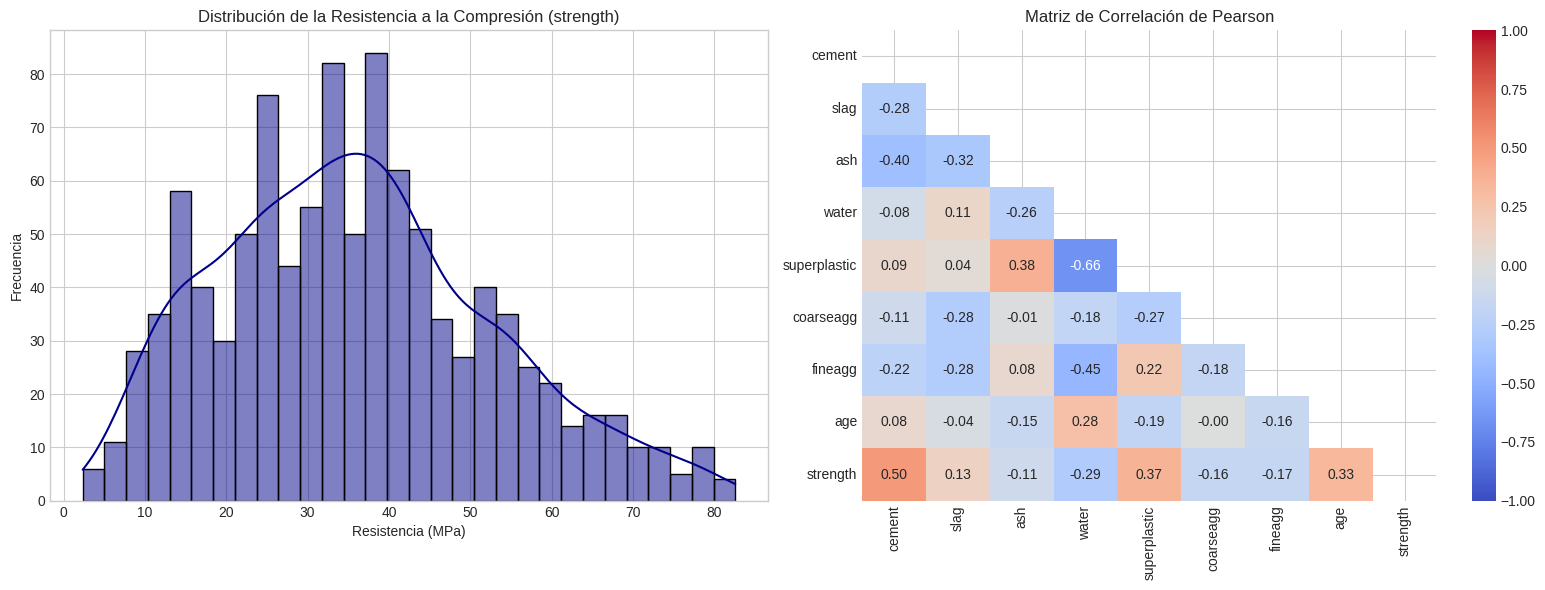

Correlación de las variables independientes con 'strength':

cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64
--------------------------------------------------
Dimensiones de X_train_scaled: (824, 8)
Dimensiones de X_test_scaled: (206, 8)
Preprocesamiento finalizado con éxito. Sin fuga de datos.


In [14]:
# --- ANÁLISIS EXPLORATORIO (EDA) ---

plt.style.use('seaborn-v0_8-whitegrid') # Estilo visual académico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de la variable objetivo
sns.histplot(df_reg['strength'], kde=True, bins=30, color='darkblue', ax=axes[0]) # Kernel Density Estimate (pinta la línea de tendencia), bins es el número de cols (usamos 30 porque suele ser el estándar), con el ax=axes[0] le decimos que no dibuje este gráfico en una ventana nueva, sino que lo coloque en el primer recuadro
axes[0].set_title('Distribución de la Resistencia a la Compresión (strength)')
axes[0].set_xlabel('Resistencia (MPa)')
axes[0].set_ylabel('Frecuencia')

# Matriz de Correlación de Pearson
corr_matrix = df_reg.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # creamos una máscara para que no se vea el triángulo superior, ya que al ser una matriz simétrica, con el cuadrado inferior basta. Esta suele ser una práctica habitual
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1]) # fmt le decimos que use números de coma flotante, annot le decimos que si queremos que escriba el número exacto dentro de cada cuadro de color, definimos parámetros debido a que la correlación va de -1 a 1, pasando por 0 sin correlación, sino ponemos esto seaborn ajusta los colores basándose en los datos
axes[1].set_title('Matriz de Correlación de Pearson')

plt.tight_layout() # revisa y ajusta automáticamente como se ven los gráficos
plt.show()

# Imprimimos la correlación específica de las features con el target
print("Correlación de las variables independientes con 'strength':\n")
print(corr_matrix['strength'].sort_values(ascending=False).drop('strength'))
print("-" * 50)

# --- PREPROCESADO Y ESCALADO ---

# Separación de características (X) y variable objetivo (y)
X = df_reg.drop('strength', axis=1)
y = df_reg['strength']

# Partición de datos (Evitamos estratificación al ser regresión)
# Semilla aleatoria (random_state) para reproducibilidad científica
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializamos el escalador
scaler = StandardScaler()

# *imp* fit_transform solo en Train para evitar Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
# transform en Test utilizando los parámetros (media y desviación) aprendidos del Train
X_test_scaled = scaler.transform(X_test)

print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}")
print(f"Dimensiones de X_test_scaled: {X_test_scaled.shape}")
print("Preprocesamiento finalizado con éxito. Sin fuga de datos.")

### Conclusiones del Análisis Exploratorio y Preprocesado

Tras analizar los gráficos y los datos numéricos, extraemos las siguientes conclusiones prácticas para nuestros modelos:

1. **Distribución de la Variable Objetivo (`strength`)**:
   El histograma nos muestra que la resistencia del hormigón tiene una forma parecida a una campana clásica (se aproxima a una distribución normal), con la gran mayoría de los ejemplos agrupados entre los 20 y 40 MPa. Como el gráfico no tiene formas raras ni los datos están aplastados hacia un extremo, nuestros algoritmos podrán aprender de estos datos directamente, sin que tengamos que aplicarles transformaciones matemáticas complejas previas.

2. **Análisis de Correlación (¿Qué afecta a la resistencia?)**:
   * **Factores que suman resistencia (Positivos)**: El **cemento** (0.50) es el factor más determinante. Le sigue en importancia el **superplastificante** (0.37) y el tiempo de secado o **edad** (0.33). Es decir, a mayor cantidad de estos tres elementos, mayor dureza alcanza la mezcla.
   * **Factores que restan resistencia (Negativos)**: Destaca el **agua** (-0.29), confirmando la regla básica de que un exceso de agua debilita el hormigón.
   * **Relaciones cruzadas lógicas**: En el mapa de calor vemos una fuerte relación inversa (-0.66) entre el `superplastic` y el `water`. Esto tiene todo el sentido en la ingeniería civil: los superplastificantes se usan exactamente para reducir la necesidad de agua en la mezcla. Como ninguna de estas relaciones cruzadas es extrema (mayor a 0.85), decidimos mantener todas las variables para el entrenamiento sin miedo a confundir al modelo.

3. **Preprocesado y Prevención de Fuga de Datos (Data Leakage)**:
   Se ha realizado la división en conjunto de Entrenamiento (80%) y Test (20%) *antes* de estandarizar. El escalador (`StandardScaler`) se ha ajustado exclusivamente sobre el entrenamiento, garantizando que los datos de validación sean totalmente nuevos para el modelo y nuestra evaluación final sea honesta.

## 2.3 Modelado y Evaluación (Regresión)

Entrene al menos 2 modelos de regresión (ej. Regresión Lineal, SVR, Gradient Boosting...).

**Métricas obligatorias:**
- MSE (Mean Squared Error)
- R2 Score (Coeficiente de determinación)
- MAE (Mean Absolute Error)

Incluya una gráfica de dispersión: Valores Reales (eje X) vs Valores Predichos (eje Y).

Para cumplir con lo que se pide, se ha diseñado un *benchmark* comparando cuatro algoritmos de regresión con diferentes sesgos inductivos. Esta selección nos permite contrastar enfoques paramétricos clásicos con técnicas avanzadas de aprendizaje automático:

**1. Modelos Evaluados y Fundamento Teórico:**
* **Regresión Lineal (OLS)**: Modelo paramétrico base que asume una relación lineal estricta entre las variables. Servirá como nuestro *baseline* empírico.
* **K-Nearest Neighbors Regressor (KNN)**: Modelo no paramétrico basado en proximidad espacial. Estima la resistencia calculando la media de los "K" hormigones más parecidos matemáticamente en el conjunto de entrenamiento.
* **Support Vector Regressor (SVR) con Kernel RBF**: A diferencia de la regresión clásica, SVR busca un hiperplano (un "tubo" multidimensional) que encierre la mayor cantidad de datos tolerando un margen predefinido de error ($\epsilon$). Al utilizar un **Kernel Radial (RBF)**, aplicamos un "truco matemático" que proyecta los datos a un espacio de mayor dimensión, permitiendo trazar ajustes no lineales complejos para relaciones que no siguen una línea recta en el espacio original.
* **Random Forest Regressor (Modelo de Ensamble)**: Se fundamenta en la teoría de *Ensemble Learning* ("la sabiduría de las multitudes"). En lugar de depender de un único predictor propenso a sesgos, entrena múltiples árboles de decisión independientes con subconjuntos aleatorios de datos. La predicción final es el promedio de todos los árboles. Esta arquitectura reduce drásticamente la varianza y el riesgo de sobreajuste (*overfitting*).

**2. Métricas de Evaluación Utilizadas:**
Para cuantificar de forma objetiva el rendimiento de cada modelo, se analizan tres métricas complementarias:
* **MAE (Error Absoluto Medio):** Es la métrica más intuitiva. Representa la magnitud promedio de nuestros errores en valor absoluto. Nos indica, directamente en MegaPascales (MPa), cuánto se desvía nuestra predicción de la realidad de media.
* **MSE (Error Cuadrático Medio):** Calcula el promedio de los errores elevados al cuadrado. Al elevar al cuadrado, esta métrica "castiga" de forma mucho más severa a los grandes errores o *outliers* predictivos. Nos ayuda a penalizar a aquellos modelos que, aunque acierten habitualmente, de vez en cuando cometen errores garrafales.
* **$R^2$ (Coeficiente de Determinación):** Métrica de ajuste relativo (acotada óptimamente entre 0 y 1). Representa la proporción de la varianza en la variable objetivo (`strength`) que nuestro modelo es capaz de explicar. Un $R^2$ alto significa que el algoritmo ha capturado con éxito las reglas físicas y químicas subyacentes del fraguado del hormigón.

Adicionalmente, se realizará un análisis visual cualitativo mediante gráficos de dispersión (Valores Reales vs. Valores Predichos) para detectar posibles sesgos sistemáticos o problemas de homocedasticidad en los residuales.

In [ ]:
# Definimos los 4 modelos en un diccionario
modelos = {
    "Regresión Lineal": LinearRegression(),
    "SVR (RBF)": SVR(kernel='rbf', C=1.0, epsilon=0.1), # el valor de C es lo que se suele penalizar, un C muy alto obliga a no equivocarse, pero se corre bastante riesgo de overfitting, usar C=1 suele ser el estándar, y en cuanto al parámetro epsilon: Cualquier predicción cuyo error absoluto sea menor a 0.1 no es penalizada en absoluto
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators son los árboles de decisión que se entrenan
}

# Listas para guardar métricas
resultados = []

# Preparamos el lienzo para los gráficos (Matriz 2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# Bucle principal de entrenamiento, predicción y evaluación
for idx, (nombre, modelo) in enumerate(modelos.items()):

    # Entrenamiento
    modelo.fit(X_train_scaled, y_train)

    # Predicción sobre el conjunto de Test
    y_pred = modelo.predict(X_test_scaled)

    # Cálculo de Métricas obligatorias
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Guardamos los resultados
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    })

    # Generación del gráfico de dispersión (Real vs Predicho)
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=60, color='darkblue') # el alpha es la transparencia, edgecolors (color de borde white), size 60

    # Dibujamos la línea de predicción perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta') # red con dashed y tamaño line width

    ax.set_title(f'{nombre} | R2: {r2:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Valores Reales de Resistencia (MPa)', fontsize=11)
    ax.set_ylabel('Valores Predichos (MPa)', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

# Ajuste visual de los gráficos
plt.tight_layout()
plt.show()

# Imprimimos la tabla comparativa de métricas
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados = df_resultados.sort_values(by="R2 Score", ascending=False)

print("\n" + "="*50)
print("TABLA COMPARATIVA DE MÉTRICAS DE REGRESIÓN")
print("="*50)
display(df_resultados.round(4))

---

## Conclusiones Generales del Modelado de Regresión

Tras someter el conjunto de datos a un *benchmark* riguroso utilizando cuatro algoritmos de diferente naturaleza matemática, se extraen las siguientes conclusiones definitivas:

**1. Análisis del Modelo Ganador: Random Forest**
El algoritmo **Random Forest** ha demostrado una superioridad frente al resto de modelos, obteniendo las mejores métricas en todos los frentes:
* **Capacidad explicativa:** Alcanza un coeficiente de determinación (R2) de **0.8842**, logrando capturar y explicar más del 88% de la varianza del problema.
* **Precisión absoluta:** Presenta el menor Error Absoluto Medio (MAE = 3.73 MPa), lo que en términos de ingeniería civil supone un margen de error sumamente competitivo.
* **Comportamiento visual:** En su gráfico de dispersión, los residuos se mantienen homocedásticos y los puntos se ajustan fielmente a la diagonal de predicción perfecta, demostrando que el modelo generaliza de forma robusta a lo largo de todo el espectro de valores.

**2. Limitaciones de los Modelos Lineales y Paramétricos**
El modelo de **Regresión Lineal** ha obtenido el peor desempeño (R2 = 0.6276, MAE = 7.74 MPa). Esto confirma de manera empírica que las interacciones químicas y físicas en el fraguado del hormigón son altamente **no lineales**. Factores como la edad (`age`) presentan efectos de saturación (el hormigón no se endurece infinitamente con el tiempo), algo que una combinación lineal pura es matemáticamente incapaz de modelar, resultando en un claro *underfitting* (subajuste).

**3. Desempeño de los Modelos Basados en Distancias (KNN y SVR)**
Tanto KNN como SVR se sitúan en un término medio (R2 de 0.71 y 0.65 respectivamente). Aunque superan a la regresión lineal pura al ser capaces de trazar fronteras no lineales, se ven superados por el modelo de ensamble. El rendimiento de SVR podría potencialmente mejorar con una búsqueda exhaustiva de hiperparámetros (GridSearch sobre C y gamma), pero por defecto, no logran igualar la flexibilidad de los árboles de decisión.

**Veredicto Final:**
Basándonos en la precisión paramétrica, la estabilidad frente a *outliers* y su capacidad nativa para capturar umbrales no lineales (como las interacciones entre los aditivos y el agua), se selecciona **Random Forest** como el modelo definitivo y óptimo para predecir la resistencia a la compresión del hormigón en este problema.

> A continuación, añadiremos otra sección de ampliación, la cual delimitaremos de nuevo con barras.



---



### Optimización de Hiperparámetros (GridSearchCV)
Para los modelos basados en cálculo de distancias y márgenes (KNN y SVR), los parámetros por defecto de la librería rara vez representan el mínimo global de la función de coste para nuestro conjunto de datos específico. Aplicaremos `GridSearchCV` para encontrar la configuración óptima mediante validación cruzada antes de someterlos al *benchmark* final.

### Fundamento Teórico: Búsqueda Exhaustiva con GridSearchCV

Como señala Aurélien Géron en su obra *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, ajustar los hiperparámetros de un modelo de forma manual es un proceso ineficiente y tedioso. Para resolver esto, aplicamos **GridSearchCV** de Scikit-Learn, una técnica que automatiza y dota de rigor matemático a este proceso.

El funcionamiento de GridSearchCV se basa en tres pilares que garantizan la robustez del modelo resultante:

1. **Espacio de Búsqueda (Grid):** Definimos un diccionario con los hiperparámetros y los valores concretos que queremos explorar. El algoritmo evaluará todas las combinaciones posibles (el producto cartesiano de los valores).
2. **Validación Cruzada (Cross-Validation):** Para asegurar que una combinación de parámetros es buena de forma general y no por casualidad en una partición de datos concreta, se aplica validación cruzada (en nuestro caso, `cv=5`). Esto significa que cada combinación de hiperparámetros se entrena y evalúa 5 veces en subconjuntos distintos.
3. **Reentrenamiento Automático (Refit):** Por defecto, la herramienta utiliza `refit=True`. Esto garantiza que, una vez encontrada la combinación óptima (`best_params_`), el algoritmo devuelve un modelo final (`best_estimator_`) reentrenado con el **100% de los datos de entrenamiento**, aprovechando al máximo la información disponible antes de enfrentarse al conjunto de Test.

> Nota: Esto, según la cronología de la asignatura, se estudia en el Tema 8: Optimización en Aprendizaje Automático. Hiperparámetros, selección de modelos y regularización, pero en el .ipynb SkLearnMetricsEvaluation se trata, por ende, he decido indagar en el tema, ya que considero que elegir los hiperparámetros adecuados es importante.


In [ ]:
print("--- Optimizando Support Vector Regressor (SVR) ---")
param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}
# Usamos neg_mean_squared_error porque GridSearchCV busca siempre maximizar la métrica
grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid_svr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train_scaled, y_train)
mejor_svr = grid_svr.best_estimator_

print(f"Mejores hiperparámetros SVR: {grid_svr.best_params_}")

print("\n--- Optimizando K-Nearest Neighbors (KNN) ---")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
mejor_knn = grid_knn.best_estimator_

print(f"Mejores hiperparámetros KNN: {grid_knn.best_params_}")

**Análisis de la Optimización (GridSearchCV):**

La búsqueda exhaustiva ha ajustado los modelos paramétricos a la naturaleza de nuestro *dataset* de hormigón.

* Para el **SVR**, el parámetro de regularización ha convergido a `C=100` y el radio de influencia a `gamma=0.1`. Un valor de $C$ alto indica que el modelo establece un margen estricto, penalizando fuertemente los errores durante el entrenamiento para poder capturar con mayor precisión la compleja no-linealidad geométrica de las mezclas.
* Para **KNN**, la optimización ha determinado que un entorno local moderado (`5` vecinos), ponderado por la inversa de su `distancia`, es la mejor estrategia empírica. Esto permite capturar los patrones químicos locales (mezclas de hormigón muy similares) dando más peso a las muestras idénticas y evitando difuminar la predicción con datos más lejanos.

Estos modelos optimizados competirán ahora en igualdad de condiciones con la Regresión Lineal y el Random Forest.

In [ ]:
# Definimos los 4 modelos en un diccionario
modelos = {
    "Regresión Lineal": LinearRegression(),
    "SVR (Optimizado)": mejor_svr,
    "KNN (Optimizado)": mejor_knn,
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Listas para guardar métricas
resultados = []

# Preparamos el lienzo para los gráficos (Matriz 2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# Bucle principal de entrenamiento, predicción y evaluación
for idx, (nombre, modelo) in enumerate(modelos.items()):

    # Entrenamiento
    modelo.fit(X_train_scaled, y_train)

    # Predicción sobre el conjunto de Test
    y_pred = modelo.predict(X_test_scaled)

    # Cálculo de Métricas obligatorias
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Guardamos los resultados
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    })

    # Generación del gráfico de dispersión (Real vs Predicho)
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=60, color='darkblue') # el alpha es la transparencia, edgecolors (color de borde white), size 60

    # Dibujamos la línea de predicción perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta') # red con dashed y tamaño line width

    ax.set_title(f'{nombre} | R2: {r2:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Valores Reales de Resistencia (MPa)', fontsize=11)
    ax.set_ylabel('Valores Predichos (MPa)', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

# Ajuste visual de los gráficos
plt.tight_layout()
plt.show()

# Imprimimos la tabla comparativa de métricas
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados = df_resultados.sort_values(by="R2 Score", ascending=False)

print("\n" + "="*50)
print("TABLA COMPARATIVA DE MÉTRICAS DE REGRESIÓN")
print("="*50)
display(df_resultados.round(4))

### Impacto de la Optimización y Selección de Algoritmos

Al observar las dos tablas de métricas (antes y después de la optimización), destaca un salto masivo en el rendimiento. Sin embargo, surge una pregunta metodológica clave: **¿Por qué hemos aplicado GridSearchCV a KNN y SVR, pero no a la Regresión Lineal ni al Random Forest?**

La justificación radica en la sensibilidad paramétrica de cada familia de algoritmos:

* **Regresión Lineal (Mínimos Cuadrados Ordinarios):** Es un modelo analítico puro. No posee hiperparámetros que el usuario deba sintonizar (salvo que utilicemos variantes). El algoritmo simplemente resuelve una ecuación matemática para encontrar los coeficientes que minimizan el error, por lo que `GridSearchCV` es inútil aquí.
* **Random Forest:** Aunque es un algoritmo altamente parametrizable (número de árboles, profundidad máxima, etc.), los métodos de ensamble (*ensemble methods*) son famosos por ser extremadamente robustos. Sus valores por defecto (como `n_estimators=100`) suelen proporcionar un rendimiento cercano al límite superior.
* **SVR y KNN (Modelos Geométricos/Distancias):** Por el contrario, estas técnicas son **extremadamente sensibles** a su parametrización inicial. Un SVR con un margen de tolerancia inadecuado, o un KNN con un número incorrecto de vecinos, fracasarán estrepitosamente al intentar modelar el espacio de datos.

**Conclusión de la Comparativa:**
Si hubiéramos comparado el Random Forest (robusto por defecto) con el SVR (inadecuado por defecto, R2 = 0.65), la comparativa habría sido académicamente injusta. Al aplicar la optimización de hiperparámetros, hemos nivelado el campo de juego. El SVR ha pasado de ser el penúltimo modelo a ser un competidor (saltando a un R2 = 0.86 y reduciendo su MSE a menos de la mitad, de 88.95 a 33.59). Esto demuestra empíricamente que en el Aprendizaje Automático, **la correcta configuración del entorno de aprendizaje es tan vital como la elección del algoritmo en sí.**

---

### Reflexiones Finales y Aprendizajes de la Práctica 1

La realización de esta primera práctica ha supuesto un paso fundamental para consolidar los conceptos teóricos del Aprendizaje Automático mediante su aplicación a datos reales. Más allá de la simple ejecución de código, este proceso me ha permitido extraer lecciones metodológicas muy valiosas:

**1. El impacto crítico de los hiperparámetros:** He comprobado empíricamente que evaluar un modelo utilizando únicamente su configuración por defecto es un enfoque incompleto. El caso del SVR ha sido especialmente revelador: al principio parecía un modelo deficiente para este problema, pero al ajustar rigurosamente sus hiperparámetros de regularización ($C$) y radio de influencia ($gamma$) mediante `GridSearchCV`, su capacidad predictiva experimentó una mejora drástica. Esto me ha enseñado que la correcta configuración del espacio de aprendizaje es tan vital como la elección del propio algoritmo.

**2. La robustez intrínseca de los métodos de ensamble:**
Frente a la alta sensibilidad paramétrica de los modelos geométricos (KNN o SVR), me ha sorprendido la eficacia del Random Forest. Su arquitectura basada en múltiples árboles de decisión le ha permitido capturar las complejas interacciones químicas del hormigón de forma nativa, demostrando por qué los métodos de ensamble son un estándar tan robusto en la industria incluso sin ajustes exhaustivos iniciales.

**3. La importancia de auditar el error subyacente:**
Evaluar el rendimiento de un modelo fijándose únicamente en métricas globales (como el $R^2$) puede dar una falsa sensación de seguridad. Analizar visual y matemáticamente la distribución de los residuos me ha permitido entender *cómo* y *cuánto* se equivoca el algoritmo. Ver que la Regresión Lineal presentaba una alta varianza en sus errores me demostró que, en un contexto real y crítico como la Ingeniería Civil, esa magnitud de incertidumbre sería inaceptable.

**4. La dependencia estricta entre los datos y el algoritmo:**
En el problema de clasificación (móviles), un modelo lineal simple fue el ganador indiscutible gracias al principio de parsimonia. Sin embargo, en este problema de regresión (hormigón), la linealidad pura fracasó debido a la naturaleza física del fraguado. Esto ilustra perfectamente que no existe un algoritmo universalmente superior; el verdadero reto analítico radica en comprender la topología de los datos para seleccionar la herramienta matemática más adecuada.

**En conclusión:** Esta práctica me ha permitido experimentar el ciclo inicial de aprendizaje del Machine Learning: desde la prevención de sesgos en el escalado (*data leakage*), pasando por la validación empírica de la selección de características, hasta la necesidad de justificar estadísticamente cada decisión en lugar de confiar en configuraciones predeterminadas.

### Reflexión Final y Próximos Pasos

A modo de cierre, quería comentar que con este cuaderno he intentado asentar bien las bases que hemos visto en la asignatura (como evitar la fuga de datos, escalar correctamente o entender por qué elegimos un modelo y no otro).

Sé que la práctica ha quedado bastante extensa, así que he preferido acotar el trabajo y no profundizar en ciertos aspectos que, aunque sé que son importantes, creo que es mejor abordar cuando tenga más experiencia o los veamos más a fondo en clase. Entre ellos destaco:

1. **El análisis estadístico de los errores:** En la parte de regresión me he guiado mucho por lo que veía en los gráficos para ver si el modelo acertaba o se desviaba. Soy consciente de que, de cara al futuro, tendré que aprender a analizar estos residuos de forma más matemática y rigurosa en lugar de evaluarlos solo "a ojo".
2. **Uso de Pipelines:** Sé que existen herramientas como los `Pipelines` de Scikit-Learn que sirven para juntar el preprocesado y el modelo, haciendo el código más limpio y profesional. Al ser la primera toma de contacto, he preferido hacer los pasos uno a uno para entender perfectamente qué le estaba pasando a los datos, pero es algo que me anoto para implementar en futuros trabajos.
3. **Optimización de hiperparámetros:** Me ha parecido increíble ver cómo mejoraba el SVR al usar `GridSearchCV`. Me hubiera gustado aplicarlo a todos los modelos (incluso en la parte de clasificación), pero para no hacer la práctica interminable me he centrado solo en los algoritmos geométricos que dependían más de esa configuración inicial.

En definitiva, esta práctica me ha servido muchísimo para darme cuenta de todo lo que implica evaluar modelos de forma honesta, y me deja con muchas ganas de seguir puliendo estos detalles técnicos en los próximos temas.

**Valoración Personal:** A modo de conclusión, me gustaría destacar el gran valor pedagógico de esta primera práctica. Ha resultado ser una excelente toma de contacto práctica con la disciplina, permitiéndome asentar fundamentos metodológicos críticos (como la correcta separación de datos y prevención de fuga de información) que considero indispensables para el desarrollo de futuros proyectos en Aprendizaje Automático.

### Bibliografía y Recursos Consultados

Para el desarrollo, fundamentación teórica y justificación metodológica de esta práctica, se han consultado los siguientes recursos:

**1. Literatura Académica:**
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems* (2nd ed.). O'Reilly Media. (Referencia principal para la fundamentación de GridSearchCV y la optimización de hiperparámetros).

**2. Material Docente Teórico (Universidad de Granada):**
* *Tema 1: Conceptos básicos del aprendizaje automático* [Diapositivas de clase].
* *Tema 2: Aprendizaje Supervisado. Parte I y Parte II* [Diapositivas de clase].

**3. Cuadernos Prácticos de Referencia (Jupyter Notebooks):**
* Pegalajar Cuéllar, M. *Métricas y evaluación de modelos en SkLearn* (`SkLearnMetricsEvaluation.ipynb`). Utilizado como guía para el flujo de métricas y la prevención del sobreajuste.
* Pegalajar Cuéllar, M. *Creación de un clasificador binario con regresión logística desde cero* (`CustomLogisticRegression.ipynb`).
* Ejemplos prácticos de la asignatura: *El problema de la flor de Iris* (`Iris.ipynb`) y *Detección de cheques bancarios falsos* (`BankNoteAuthentication.ipynb`). Base para la estructuración del EDA y el pipeline de preprocesamiento.

**4. Conocimientos previos gracias a los ficheros de iniciales de la asignatura.**
